## NIMOハンズオン (関数の最適化)

In [1]:
import sys
sys.path.append('..')
import nimo
import yaml
import shutil

In [2]:
# Parameters cell for papermill
config_file = "conservative_yaml.tmpl.yaml"  # This will be overwritten by papermill

In [3]:
# Parameters
config_file = "/Users/shibukawar/workspace/nimo-fork/multi_batch_experiments_melting_temperature/./configs/nts_conservative_batch15_trial4.yaml"


In [4]:
# Load configuration from YAML file
with open(config_file, "r") as f:
    config = yaml.safe_load(f)

### AIとロボットのサイクルの回数を設定

In [5]:
# CyclesNum = config["cycles_num"])

### 目的関数の次元を設定

In [6]:
ObjectivesNum = config["objectives_num"]

In [7]:
from al_mg_zn import AlMgZnMeltingPoint
des = AlMgZnMeltingPoint()

### 実験条件候補データファイル名および提案条件のファイル名を設定

In [8]:
from pathlib import Path

TRIAL = config["trial"]
BATCH_SIZE = config["batch_size"]
TOTAL_EVAL = config["total_eval"]
INITIAL_BATCH_SIZE = config["initial_batch_size"]
print(f"Initial Batch Size: {INITIAL_BATCH_SIZE}")
CyclesNum = int((TOTAL_EVAL - INITIAL_BATCH_SIZE) / BATCH_SIZE)
print(f"CyclesNum: {CyclesNum}")
NTS_MODE = config["nts_mode"]
RE_SEED = config["re_seed"]
USE_DPP = config["use_dpp"]

if NTS_MODE == "conservative":
    MODE = nimo.Mode.conservative
elif NTS_MODE == "moderate":
    MODE = nimo.Mode.moderate
elif NTS_MODE == "aggressive":
    MODE = nimo.Mode.aggressive
print(MODE)

# Create output directory with batch size in name
out_dir = Path(f"./data_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}")
out_dir.mkdir(exist_ok=True, parents=True)
(out_dir / "fig").mkdir(exist_ok=True, parents=True)

# Copy setting yaml file to output directory
shutil.copy(config_file, out_dir / Path(config_file).name)

Initial Batch Size: 15
CyclesNum: 2
Mode.conservative


PosixPath('data_conservative_batch15_trial4/nts_conservative_batch15_trial4.yaml')

In [9]:
candidates_file = out_dir / f"mp_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
proposals_file = out_dir / f"mp_proposals_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"

# Copy initial search space to output directory if not exists
import os
initial_search_space = f"./mp_search_space_{NTS_MODE}_batch{BATCH_SIZE}_trial{TRIAL}.csv"
if os.path.exists(initial_search_space) and not os.path.exists(candidates_file):
    shutil.copy(initial_search_space, candidates_file)

### 結果を格納する場所を作成

In [10]:
res_history = nimo.history(input_file = str(candidates_file),
                             num_objectives = ObjectivesNum)

### 最適化計算

In [11]:
import time
start = time.time()
for K in range(CyclesNum+1):

    #最初のサイクルではランダムに実験条件を提案させる
    if K == 0:
        nimo.selection(method = "RE",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = INITIAL_BATCH_SIZE,
                       re_seed = RE_SEED)

    #2回目以降のサイクルではAIを使用して実験条件を提案
    #PHYSBO: ベイズ最適化
    #BLOX: 無目的探索
    #PDC: 相図探索
    #RE: ランダム
    else:
        nimo.selection(method = "NTS",
                       input_file = str(candidates_file),
                       output_file = str(proposals_file),
                       num_objectives = ObjectivesNum,
                       num_proposals = BATCH_SIZE,
                       sample_mode=MODE,
                       use_dpp=USE_DPP,
                       output_res=True)

    #実験条件に従い，ロボット実験のインプットファイルを作成する
    #今回は，inputfile.txtファイルを作成するだけのモジュール
    import preparation_input_functions
    preparation_input_functions.ORIGINAL(input_file = str(proposals_file),
                                         input_folder = str(out_dir)).perform()


    #実験終了後，測定データを解析し，目的関数をアップデートする
    #今回は，関数値を計算し，目的関数とするanalysis_output_functions.pyを利用する
    import analysis_output_functions_SO_melting_point
    analysis_output_functions_SO_melting_point.ORIGINAL(input_file = str(proposals_file),
                                       output_file = str(candidates_file),
                                       num_objectives = ObjectivesNum,
                                       output_folder = str(out_dir)).perform()

    #結果をプロットするためのhistoryを格納する
    res_history = nimo.history(input_file = str(candidates_file),
                               num_objectives = ObjectivesNum,
                               itt = K,
                               history_file = res_history)

    #結果のヒストグラムを作成するモジュールを読み出す
    if K % 5 == 0:
        import time
        time.sleep(1)
        nimo.visualization.plot_distribution.plot(input_file = str(candidates_file),
                                                  num_objectives = ObjectivesNum,
                                                  fig_folder = str(out_dir / "fig"))

    #結果の相図を作成するモジュールを読み出す
    #if K % 5 == 0:
    #    import time
    #    time.sleep(1)
    #    nimo.visualization.plot_phase_diagram.plot(input_file = candidates_file,
    #                                               fig_folder = "./fig")
end = time.time()
print(f"Elapsed time: {end - start} [s]")

Start selection of proposals by RE!
Proposals
###
number = 1
actions =  435
proposal =  [18. 24.]
###
###
number = 2
actions =  647
proposal =  [28. 48.]
###
###
number = 3
actions =  1011
proposal =  [52. 20.]
###
###
number = 4
actions =  397
proposal =  [16. 34.]
###
###
number = 5
actions =  814
proposal =  [38. 32.]
###
###
number = 6
actions =  853
proposal =  [40. 46.]
###
###
number = 7
actions =  1263
proposal =  [80.  6.]
###
###
number = 8
actions =  347
proposal =  [14. 22.]
###
###
number = 9
actions =  1289
proposal =  [84. 16.]
###
###
number = 10
actions =  396
proposal =  [16. 32.]
###
###
number = 11
actions =  863
proposal =  [42.  4.]
###
###
number = 12
actions =  1145
proposal =  [64. 18.]
###
###
number = 13
actions =  470
proposal =  [20. 10.]
###
###
number = 14
actions =  375
proposal =  [14. 78.]
###
###
number = 15
actions =  948
proposal =  [48.  0.]
###
Finish selection of proposals!
Start preparation input!
Finish preparation input!
Start analysis output!

Start selection of proposals by NTS!
--------------------------------------------------------------------------------
         Use physbo.search.discrete.Policy instead.
--------------------------------------------------------------------------------


lstar: 840.06


Selected actions: [np.int64(493), np.int64(1224), np.int64(1294), np.int64(269), np.int64(1227), np.int64(1191), np.int64(1316), np.int64(131), np.int64(1290), np.int64(406), np.int64(124), np.int64(1212), np.int64(1277), np.int64(1270), np.int64(173)]
Proposals
###
number = 1
actions =  493
proposal =  [20. 56.]
###
###
number = 2
actions =  1224
proposal =  [74.  6.]
###
###
number = 3
actions =  1294
proposal =  [86.  8.]
###
###
number = 4
actions =  269
proposal =  [10. 48.]
###
###
number = 5
actions =  1227
proposal =  [74. 12.]
###
###
number = 6
actions =  1191
proposal =  [70.  2.]
###
###
number = 7
actions =  1316
proposal =  [94.  0.]
###
###
number = 8
actions =  131
proposal =  [ 4. 60.]
###
###
number = 9
actions =  1290
proposal =  [86.  0.]
###
###
number = 10
actions =  406
proposal =  [16. 52.]
###
###
number = 11
actions =  124
proposal =  [ 4. 46.]
###
###
number = 12
actions =  1212
proposal =  [72. 12.]
###
###
number = 13
actions =  1277
proposal =  [82. 12.]
#

lstar: 858.908


Selected actions: [np.int64(11), np.int64(1317), np.int64(1322), np.int64(1283), np.int64(1271), np.int64(1310), np.int64(1274), np.int64(1299), np.int64(1284), np.int64(1324), np.int64(1314), np.int64(1281), np.int64(1296), np.int64(1308), np.int64(1285)]
Proposals
###
number = 1
actions =  11
proposal =  [ 0. 22.]
###
###
number = 2
actions =  1317
proposal =  [94.  2.]
###
###
number = 3
actions =  1322
proposal =  [96.  4.]
###
###
number = 4
actions =  1283
proposal =  [84.  4.]
###
###
number = 5
actions =  1271
proposal =  [82.  0.]
###
###
number = 6
actions =  1310
proposal =  [90. 10.]
###
###
number = 7
actions =  1274
proposal =  [82.  6.]
###
###
number = 8
actions =  1299
proposal =  [88.  2.]
###
###
number = 9
actions =  1284
proposal =  [84.  6.]
###
###
number = 10
actions =  1324
proposal =  [98.  2.]
###
###
number = 11
actions =  1314
proposal =  [92.  6.]
###
###
number = 12
actions =  1281
proposal =  [84.  0.]
###
###
number = 13
actions =  1296
proposal =  [86.

### 目的関数の推移を出力

In [12]:
nimo.visualization.plot_history.cycle(input_file = res_history,
                                      num_cycles = CyclesNum,
                                      fig_folder = str(out_dir / "fig"))

In [13]:
import numpy as np
tmp = []
X_tmp = []
for r in res_history:
    tmp.append(r[2][0])
    X_tmp.append(r[1])

tmp = np.array(tmp)
X_tmp = np.array(X_tmp)

In [14]:
from collections import defaultdict
sample_by_iter, objective_by_iter = defaultdict(list), defaultdict(list)
for r in res_history:
    objective_by_iter[r[0]].append(r[2][0])
    sample_by_iter[r[0]].append(r[1])

dict_keys([1, 2, 3])


Text(0, 0.5, 'Objective')

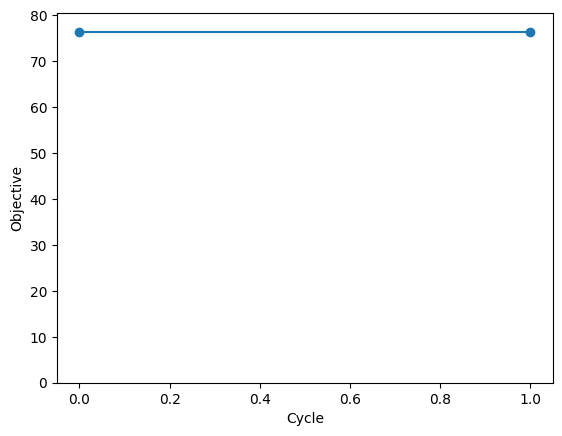

In [15]:
import matplotlib.pyplot as plt

print(objective_by_iter.keys())

fig, ax = plt.subplots()
tmp_history = [des.get_regret(max(objective_by_iter[1]))]
for i in range(1, CyclesNum):
    tmp_history.append(min(tmp_history[-1], des.get_regret(max(objective_by_iter[i]))))
ax.plot(range(CyclesNum), tmp_history, marker="o")
ax.set_xlabel("Cycle")
ax.set_ylim(0)
ax.set_ylabel("Objective")

In [16]:
# Save nested list object
import pickle
with open(out_dir / "objective_by_iter.pkl", "wb") as f:
    pickle.dump(objective_by_iter, f)
with open(out_dir / "sample_by_iter.pkl", "wb") as f:
    pickle.dump(sample_by_iter, f)